# 1. Carregando um Dataset

[EEGDash](https://eegdash.org/) é uma biblioteca Pythoncom 700+ datasets de EEG Open-Source. [EEGDash-Paper](https://arxiv.org/abs/2606.16041)

## 1.1 Setup

Para encontrar datasets, podemos verificar o [Catálogo](https://eegdash.org/dataset_summary.html). Vamos utilizar o Dataset [DS002721 - EEG data investigating neural correlates of music-induced emotion](https://eegdash.org/api/dataset/eegdash.dataset.DS002721.html).

Descrição do Dataset: The purpose of the research activity in which the data were collected was to investigate the EEG neural correlates of music-induced emotion. For this purpose 31 healthy adult participants listened to 40 music clips of 12 s duration each, targeting a range of emotional states. The music clips comprised excerpts from film scores spanning a range of styles and rated on induced emotion. The dataset contains **unprocessed EEG data** from all 31 participants (age range 18-66, 18 female) while listening to the music clips, together with the reported induced emotional responses . **The paradigm involved 6 runs of EEG recordings**. **The first and last runs were resting state runs, during which participants were instructed to sit still and rest for 300 s**. **The other 4 runs each contained 10 music listening trials**.

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

import eegdash
from eegdash import EEGDashDataset
from eegdash.viz import style_figure, use_eegdash_style

# Force MNE's matplotlib browser so raw.plot returns a Figure (the Qt
# browser returns an MNEQtBrowser instance and skips static capture).
mne.viz.set_browser_backend("matplotlib")

use_eegdash_style() # Configura matplotlib/seaborn para plots EEG
cache_dir = os.environ.get("EEGDASH_CACHE_DIR", str(Path.home() / ".eegdash_cache")) # /home/user/.eegdash_caache -> Onde são baixados os datasets
print(f"eegdash {eegdash.__version__}; cache_dir={cache_dir}")

Using matplotlib as 2D backend.
eegdash 0.8.4; cache_dir=/home/arielalves/.eegdash_cache


## 1.2 Conceitos por trás do EEGDashDataset

- **Metadata index vs. file blobs** - O EEGDash separa *records* (pequenos arquivos JSON) de *files* (BIDS payloads no OpenNeuro / S3). Uma query busca apenas os metadados, os bytes brutos esperam.

- **Lazy by default** - `EEGDashDataset` retorna imediatamente, sem baixar nada da rede. Cada entrada de registro possui a propriedade `raw`, e o download (apenas para aquele registro) ocorre na primeira vez que essa propriedade é lida.

- **Herança do Braindecode** - `EEGDashDataset` é um `braindecode.datasets.BaseConcatDataset`. Qualquer código que aceita esse tipo (como `create_fixed_length_windows(ds, ...)`, `DataLoader(ds, ...)`, `Preprocessor(...)`) aceita um `EEGDashDataset` de igual modo.


*BIDS - Brain Imaging Data Structure. Padrão internacional para ogranizar e compartilhar dados de exames fMRI, EEG e MEG.

## Conceitos por trás do EEGDashDataset

- **Metadata index vs. file blobs** - O EEGDash separa *records* (pequenos arquivos JSON) de *files* (BIDS payloads no OpenNeuro / S3). Uma query busca apenas os metadados, os bytes brutos esperam.

- **Lazy by default** - `EEGDashDataset` retorna imediatamente, sem baixar nada da rede. Cada entrada de registro possui a propriedade `raw`, e o download (apenas para aquele registro) ocorre na primeira vez que essa propriedade é lida.

- **Herança do Braindecode** - `EEGDashDataset` é um `braindecode.datasets.BaseConcatDataset`. Qualquer código que aceita esse tipo (como `create_fixed_length_windows(ds, ...)`, `DataLoader(ds, ...)`, `Preprocessor(...)`) aceita um `EEGDashDataset` de igual modo.


*BIDS - Brain Imaging Data Structure. Padrão internacional para ogranizar e compartilhar dados de exames fMRI, EEG e MEG.

## 1.3 Buscando o Dataset

Ao buscar o dataset, serão baixados os metadados apenas.

In [3]:
from eegdash.dataset import DS002721

DATASET = "ds002721"
SUBJECT = "001"

# Seleciona todos
#dataset = DS002721(cache_dir="./data") # Seleciona todos

# Seleciona 1

dataset = DS002721(cache_dir="./data", subject="01") 

# Seleciona vários

# dataset = DS002721(
#     cache_dir="./data",
#     query={"subject": {"$in": ["01", "02"]}},
# )

dataset

[09/02/26 09:12:14] WARNING  Falling back to direct .edf reader for sub-01_task-run3_eeg.edf (bypassing  ]8;id=5931128;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931129;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

<BaseConcatDataset | 6 EEGDashRaw(s) | 2791000 total samples>
  Sfreq*: 1000.0 Hz
  Channels*: 19 (19 EEG)
  Ch. names*: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, ... (+9 more)
  Duration*: 552.0 s
  (* from first recording)
  Description: 6 recordings × 7 columns [subject, task, age, sex, session, run, gender]

## 1.4 Pegando uma gravação

A classe `EEGDashDataset` possui uma lista `EEGDashDataset.datasets` com as entradas de registro, onde cada entrada é uma classe `EEGDashBaseDataset` carregando um caminho BIDS, uma descrição e uma propriedade `raw` lazy (em espera). 

`record.raw` ativa o download, e devolve um objeto `mne`*.

*Ferramenta para processamento de sinais EEG e MEG.

In [4]:
record = dataset.datasets[0]
raw = record.raw

raw

<RawEDF | sub-01_task-run3_eeg.edf, 19 x 552000 (552.0 s), ~19 KiB, data not loaded>

## 1.5 Plotando o sinal

Rode `raw.plot` para renderizar uma janela de 8s em uma pequena seleção de canais.

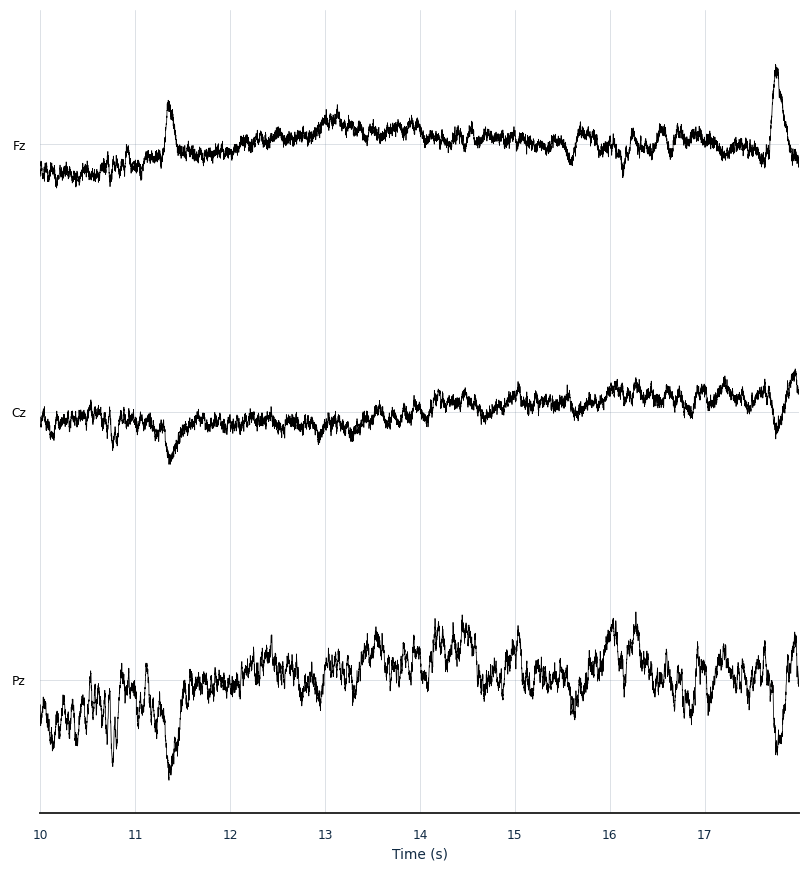

In [5]:
midline_picks = [
    ch
    for ch in ("Fz", "Cz", "Pz", "Oz", "FCz", "CPz", "POz", "T7", "T8")
    if ch in raw.ch_names
][:8]

fig_raw = raw.plot(
    start=10.0, #Início (s)
    duration=8.0, #Duração (s)
    picks=midline_picks if midline_picks else None, #Canais
    n_channels=8, #Número de canais
    scalings={"eeg": 50e-6}, #Escala
    show=True,
    show_scrollbars=False,
    show_scalebars=False,
    title="",
)

## 1.6 Topologia dos sensores

A posição dos eletrodos importa para análise posterior. `raw.plot_sensors` desenha um esquemático de uma cabeça 2D, com 74 canais possíveis.

O dataset ds002721 usa o layout 10-20 padrão (Fp1, Fp2, F3, F4, ... Cz, Pz, 19 eletrodos). `standard_1020` cobre todos eles.

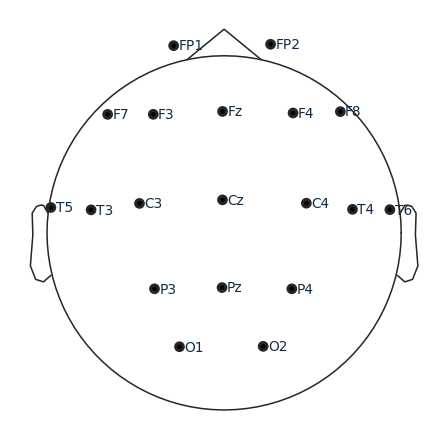

In [6]:
raw.set_montage(
    "standard_1020", #Padrão internacional
    match_case=False,
    match_alias=True,
    on_missing="ignore", #Se canal não existir, ignora
)
has_positions = any(not np.allclose(ch["loc"][:3], 0.0) for ch in raw.info["chs"])
fig_sens, ax_sens = plt.subplots(figsize=(5.0, 5.0))
if has_positions:
    raw.plot_sensors(
        kind="topomap",
        show_names=True,
        axes=ax_sens,
        show=True,
    )
    ax_sens.set_title("")
else:
    ax_sens.text(
        0.5,
        0.5,
        "Sensor positions unavailable in this build's montage",
        ha="center",
        va="center",
    )
    ax_sens.set_axis_off()
fig_sens.tight_layout()

## 1.7 Densidade espectral de energia

Um PSD é uma boa primeira impressão da qualidade do sinal: ruídos de linha em 50/60 Hz, slow drifts abaixo de 1 Hz, broadband 1/f. Computamos Welch's PSD nos canais EEG e plotamos em dB.

Plotting power spectral density (dB=True).


/home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


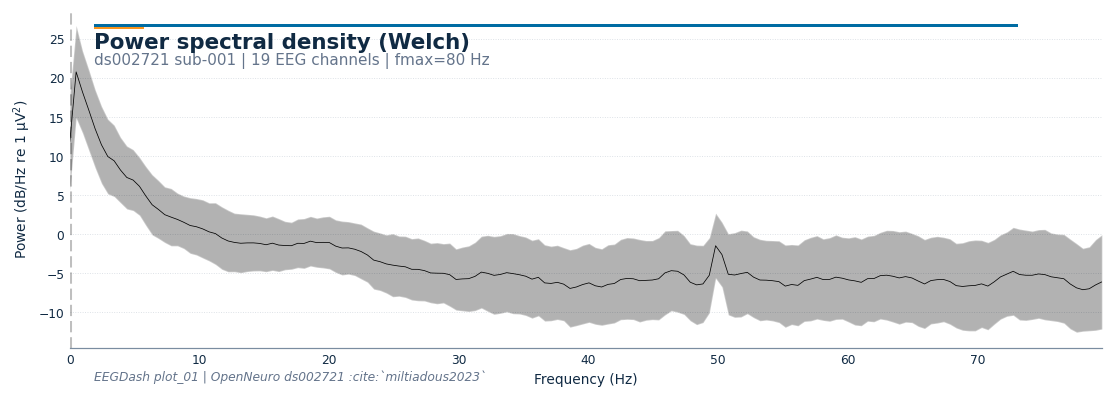

In [7]:
psd = raw.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="Power spectral density (Welch)",
    subtitle=f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels | fmax=80 Hz",
    source=f"EEGDash plot_01 | OpenNeuro {DATASET} :cite:`miltiadous2023`",
)
plt.show()

A Densidade Espectral de Potência (PSD - Power Spectral Density) mede a quantidade de energia (potência) presente em cada faixa de frequência de um sinal. No EEG, ela quantifica a força dos ritmos cerebrais (Delta, Theta, Alfa, Beta, Gama).

O Método de Welch é a abordagem padrão para estimar a PSD porque resolve um problema clássico: aplicar uma Transformada de Fourier (FFT) diretamente no sinal inteiro gera um espectro muito ruidoso e instável.

Como o Método de Welch Funciona (Passo a Passo)

1. Divisão em segmentos: O sinal contínuo é fatiado em blocos menores com sobreposição (tipicamente 50% de overlap).
2. Janelamento (Windowing): Aplica-se uma função de suavização (geralmente Janela de Hanning ou Hamming) em cada segmento para atenuar as bordas e evitar o vazamento espectral (spectral leakage).
3. Cálculo da FFT: A FFT é calculada individualmente para cada um dos segmentos janelados.
4. Média: Calcula-se a média do espectro de todos os segmentos.

A grande vantagem é que essa média reduz drasticamente a variância do ruído aleatório, gerando curvas de potência suaves e confiáveis, à custa de uma pequena perda de resolução de frequência.

# 2. Gravação EEG para DataLoader do PyTorch

Um modelo treina em tensor batches, não em traços contínuos de voltagem. Precisamos dividir a gravação EEG longa e contínua em vários tensores de tamanhos iguais para serem processados pela rede.

## 2.1 Setup

In [81]:
import braindecode
from braindecode.preprocessing import (
    Preprocessor,
    create_fixed_length_windows,
    create_windows_from_events,
    preprocess,
)

import torch
from torch.utils.data import DataLoader

## 2.2 Dataset vs Dataloader

A classe `torch.utils.data.Dataset` é para armazenamento e recuperação de dados. A classe `torch.utils.data.DataLoader` consome o dataset e adiciona: 

- **batching (Agrupamento)** - Agrupa múltiplos exemplos do dataset em lotes (batches) para processamento paralelo.

- **shuffling** - Mistura a ordem dos dados antes de dividi-los em lotes a cada época de treinamento. Evita que a rede decore sequências.

- **worker orchestration** - Coordenação de múltiplos processos para ler do disco, decodificar e aplicar transformações nos dados em paralelo. Previne gargalos de I/O na CPU.

Mas não armazena dados. É um iterável que, por trás, chama `__getitem__` no dataset e empilha os resultados.

```text
EEGDashDataset                  WindowsDataset                DataLoader
(records + BIDS meta)           (cut samples for the model)   (consumer)
┌────────────────────┐          ┌───────────────────┐         ┌────────────┐
│ record 0 (Raw) ──┐ │ preproc  │ window 0 (X, y)   │ batch + │ batch 0    │
│ record 1 (Raw) ──┼─┼─────────▶│ window 1 (X, y)   │ shuffle │ batch 1    │
│ record 2 (Raw) ──┘ │ + cut    │ ...               │────────▶│ ...        │
│ ...                │ windows  │ window N (X, y)   │         │ batch K    │
└────────────────────┘          └───────────────────┘         └────────────┘
  __len__  = n_records           __len__  = n_windows           iter() yields
  __getitem__ -> (raw, ...)       __getitem__ -> (X, y, idx)      stacked tensors
```

## 2.3 Corolários

- **Uma amostra é uma janela, não uma gravação inteira** - Um EEG contínuo é um array longo por sessão. Modelos treinam em frames de tamanho-fixo, então o pipeline corta cada `raw` em tensores `(n_channels, window_samples)` antes de qualquer batch acontecer.

- **Dois tipos de janelas** - `brandecode.preprocessing.create_fixed_lenght_windows` avança através do sinal contínuo, ignorando eventos, útil para pré-treino auto-supervisionado e estágio de sono. `braindecode.preprocessing.create_windows_from_events` corta em volta de eventos BIDS com offsets explícitos. Essa é a escolha certa para ERP e tarefas relacionadas.

- **Acesso aleatório vs armazenamento sequencial** - O treino embaralha as janelas. Para selecionar um `X[i]` aleatório, o custo de acesso cresce linearmente com o tamanho do arquivo. Zarr armazena blocos de tamanho-fixo e lê qualquer janela em dezenas de milissegundos.

## 2.4 Pegando dataset

In [26]:
dataset = DS002721(cache_dir="./data", subject="01")
dataset

[09/02/26 09:25:23] WARNING  Falling back to direct .edf reader for sub-01_task-run3_eeg.edf (bypassing  ]8;id=5931206;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931207;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

<BaseConcatDataset | 6 EEGDashRaw(s) | 2791000 total samples>
  Sfreq*: 1000.0 Hz
  Channels*: 19 (19 EEG)
  Ch. names*: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, ... (+9 more)
  Duration*: 552.0 s
  (* from first recording)
  Description: 6 recordings × 7 columns [subject, task, age, sex, session, run, gender]

Aqui, **Total Samples** significa o número total de pontos no tempo coletados.

In [ ]:
record = dataset.datasets[0]
raw = record.raw

raw

<RawEDF | sub-01_task-run3_eeg.edf, 19 x 552000 (552.0 s), ~19 KiB, data not loaded>

In [28]:
n_channels = len(raw.ch_names)
n_channels

19

In [29]:
sfreq = float(raw.info["sfreq"])
sfreq

1000.0

## 2.5 Dois pré-processamentos seguros

1. Como `raw.info['sfreq']` vai ficar após um resample de 100Hz (intervalo entre pontos mudar de 1ms para 10ms)?
2. Como `len(raw.ch_names)` vai ficar após remover os canais que não são EEG?

`pick_types(eeg=True)` mantém apenas EEG, e `resample(sfreq=100)` faz o resampling.

In [ ]:
TARGET_SFREQ = 100  # Hz

preprocess(
    dataset,
    [
        Preprocessor("pick_types", eeg=True, eog=False, misc=False), #Mantém apenas canais EEG
        Preprocessor("resample", sfreq=TARGET_SFREQ), #Muda amostragem para 100Hz
    ],
)

raw = dataset.datasets[0].raw
n_channels = len(raw.ch_names)
sfreq = float(raw.info["sfreq"])

# imprime tudo em um dataset pandas
pd.Series(
    {
        "n_channels": n_channels,
        "sfreq (Hz)": sfreq,
        "dtype": str(raw.get_data().dtype),
    },
    name="value",
).to_frame()

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


[09/02/26 09:25:36] WARNING  Falling back to direct .edf reader for sub-01_task-run2_eeg.edf (bypassing  ]8;id=5931212;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931213;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


[09/02/26 09:25:38] WARNING  Falling back to direct .edf reader for sub-01_task-run1_eeg.edf (bypassing  ]8;id=5931218;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931219;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

...

[09/02/26 09:25:43] WARNING  Falling back to direct .edf reader for sub-01_task-run5_eeg.edf (bypassing  ]8;id=5931230;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931231;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


[09/02/26 09:25:46] WARNING  Falling back to direct .edf reader for sub-01_task-run6_eeg.edf (bypassing  ]8;id=5931236;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931237;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


,value
n_channels,19
sfreq (Hz),100.0
dtype,float64


Temos 19 canais.

## 2.6 Cortar em janelas de tamanho-fixo

- `window_size_samples = int(WINDOW_SECONDS * TARGET_SFREQ)` **(Tamanho da Janela)** - Quantidade de pontos em cada janela. Para ter uma janela de 2 segundos gravando a 100 Hz (100 pontos por segundo), então uma só amostra/janela deverá terá 200 pontos.

- `window_stride_samples` **(Passo/Stride)**- Quantos pontos a janela pula para frente antes de cortar a próxima.
    - _Passo = Tamanho_ - Janelas consecutivas sem sobreposição (0% overlap)
    - _Passo menor_ - Cria sobreposição (overlap). Isso gera mais janelas, mas elas compartilham dados.

Diferença entre size e stride:
- Size = 200, stride = 100 -> Anda 100, pega 200 (com sobreposição)
- Size = 200, stride = 200 -> Anda 200, pega 200 (0% sobreposição)
- Size = 200, stride = 300 -> Anda 300, pega 200 (pula 100 pontos a cada passo)

In [ ]:
WINDOW_SECONDS = 2.0
window_size_samples = int(WINDOW_SECONDS * TARGET_SFREQ)
windows = create_fixed_length_windows(
    dataset,
    window_size_samples=window_size_samples,
    window_stride_samples=window_size_samples,  # 0 % overlap
    drop_last_window=True,
    preload=True,
)
X_one, y_one, _idx = windows[0]

windows

<BaseConcatDataset | 6 EEGWindowsDataset(s) | 1395 total samples>
  Sfreq*: 100.0 Hz
  Channels*: 19 (19 EEG)
  Ch. names*: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, ... (+9 more)
  (* from first recording)
  Description: 6 recordings × 7 columns [subject, task, age, sex, session, run, gender]
  Window: 200 samples (2.000 s)
  Targets: 1 unique ({-1: 1395})

Aqui, **Total Samples** significa o número total de janelas geradas. 1395 * 200 = 279000

Originalmente, tínhamos 2791000 a 1000Hz. Com downsampling para 100Hz, ficam 279100 pontos. Com as janelas, os últimos 100 pontos são jogados fora por não completarem a janela.

In [52]:
X_one

array([[-3.48153582e-04, -3.53973621e-04, -3.62332736e-04, ...,
        -3.12824995e-04, -2.70037126e-04, -2.40948735e-04],
       [-1.55182177e-04, -1.60386087e-04, -1.72169544e-04, ...,
        -1.24405371e-04, -8.02479262e-05, -4.58610848e-05],
       [-5.53500031e-05, -5.96929567e-05, -6.83775361e-05, ...,
         2.89998479e-06,  2.29673387e-05,  2.92474215e-05],
       ...,
       [-1.16368210e-04, -1.26511572e-04, -1.25156017e-04, ...,
        -1.14741939e-04, -1.19933640e-04, -1.19406024e-04],
       [ 2.38256271e-05,  1.01900177e-05,  5.36690459e-06, ...,
         2.24102423e-05,  1.42429490e-05,  7.77352216e-06],
       [ 3.58457473e-05,  3.08178569e-05,  2.79243050e-05, ...,
         2.73667374e-05,  1.93020951e-05,  1.79931321e-05]],
      shape=(19, 200), dtype=float32)

In [41]:
y_one

-1

In [43]:
_idx

[0, 0, 200]

Cada `windows[i]` é uma única janela.

- `windows[i][0] = X_one` = Dados do sinal `(n_canais, amostras)`
- `windows[i][1] = y_one` = Rótulo (target). O target fica marcado como `-1` se não houver rótulo específico de tarefa/evento.
- `windows[i][2] = _idx` = Lista/Tupla de índices que Braindecode usa para rastrear a origem da janela, com:
    - `_idx[0]` =  índice da gravação original de onde a janela veio
    - `_idx[1]` = Ponto de início da janela no sinal contínuo original
    - `_idx[2]` = Ponto de fim da janela no sinal contínuo original

In [60]:
# Imprime tudo em um dataset pandas
pd.Series(
    {
        "n_windows": len(windows),
        "windows[0][0].shape": str(tuple(X_one.shape)),
        "X.dtype": str(X_one.dtype),
        "window_samples": window_size_samples,
        "window_seconds": WINDOW_SECONDS,
    },
    name="value",
).to_frame()

,value
n_windows,1395
windows[0][0].shape,"(19, 200)"
X.dtype,float32
window_samples,200
window_seconds,2.0


## 2.7 Colocando em um DataLoader

Apenas quatro argumentos importam para o `DataLoader` em EEG.

- `batch_size` - De 8 a 32 é um intervalo confortável para rodar na CPU.
- `shuffle` - `True` para treinamento, `False` para avaliação.
- `num_workers` - `0` (síncrono) é o padrão correto com `preload=True`, pois as janelas já vivem na RAM. `>0` ajuda somente quando o dataset lê do disco por `_getitem_`.
- `pin_memory` - Defina para `True` se um dispositivo CUDA estiver presente e você planeja enviar batches com `.to(device, non_blocking=True)`

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
BATCH_SIZE = 8

gen = torch.Generator().manual_seed(SEED)
loader = DataLoader(
    windows,               # Janelas criadas
    batch_size=BATCH_SIZE, # Divide em lotes de tamanho BATCH_SIZE
    shuffle=True,          # Embaralhar
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=gen,         # Gerador responsável pelo embaralhamento
)
X_batch, y_batch, _idx_batch = next(iter(loader))

# Imprime informações
pd.Series(
    {
        "X.shape": str(tuple(X_batch.shape)),
        "X.dtype": str(X_batch.dtype),
        "y.shape": str(tuple(y_batch.shape)),
        "y unique": str(torch.unique(y_batch).tolist()),
        "pin_memory": loader.pin_memory,
        "num_workers": loader.num_workers,
    },
    name="value",
).to_frame()

 O DataLoader é apenas o objeto principal de configuração, que guarda as regras: qual é o dataset, tamanho do batch, shuffle, etc. Ele não sabe em qual lote você está no momento.

Quando se roda `iter(loader)`, gera-se um iterador. é ele que busca os dados na memória, empilha os tensores e rastreia o índice atual do lote.

O loop for secretamente faz next(loader) a cada passo.

In [74]:
X_batch.shape

torch.Size([8, 19, 200])

In [75]:
y_batch

tensor([-1, -1, -1, -1, -1, -1, -1, -1])

In [76]:
_idx_batch

[tensor([235, 114, 192, 134,  53,  29, 101, 185]),
 tensor([47000, 22800, 38400, 26800, 10600,  5800, 20200, 37000]),
 tensor([47200, 23000, 38600, 27000, 10800,  6000, 20400, 37200])]

As janelas foram agrupadas em lotes/batches de 8.

## 2.8 Janelas Contínuas vs Event-Based Epochs

As duas funções pegam o `Raw` e levam a `(n_epochs, n_channels, n_times)`.

- `braindecode.preprocessing.create_fixed_length_windows`
    - Avança sobre o sinal contínuo e rotula toda janela com o mesmo rótulo (target) extraído dos metadados gerais daquela gravação.
    - Ideal para pré-treinamento auto-supervisionado, classificação de estágios de sono ou monitoramento contínuo onde o rótulo pertencec à sessão inteira.

- `braindecode.preprocessing.create_windows_from_events`
    - Lê anotações `mne.io.Raw.annotations` (BIDS `events.tsv` é carregado automaticamente pelo EEGDash), e define uma única janela de tamanho fixo para cada evento usando `trial_start_offset_samples`/`trial_stop_offset_samples` (você que decide), usando o código do evento como target.
    - Ideal para ERP e decodificação relacionada a eventos.
    - `trial_start_offset_samples` - Após quantos pontos do instante do evento começa a janela?
    - `trial_stop_offset_samples` - Após quantos pontos do instante do evento termina a janela?

`events.tsv` somente possui o exato instante em que ocorreu o estímulo. A janela é você quem decide.

In [79]:
# Corta janelas de 2 segundos (window_size_samples = sfreq * 2)
windows_continuous = create_fixed_length_windows(
    dataset,
    start_offset_samples=0,     # Início
    stop_offset_samples=None,   # Fim
    window_size_samples=200,    # Quantidade de pontos por janela
    window_stride_samples=200,  # Sobreposição (0%)
    drop_last_window=True,      # Deleta janela incompleta (sobra)
)

# windows_continuous[0] retorna: (X, y, window_info)
# X tem formato (19, 200) e todas as janelas dessa gravação terão o mesmo y

In [ ]:
# Inspecionar anotações do primeiro registro
print(dataset.datasets[0].raw.annotations.description)

if(len(dataset.datasets[0].raw.annotations.description) != 0):
    windows_events = create_windows_from_events(
        dataset,
        trial_start_offset_samples=0,         # Início da janela a partir do instante do evento
        trial_stop_offset_samples=100,        # Fim da janela a partir do instante do evento
        mapping={"face": 0, "scrambled": 1},  # converte as anotações textuais em inteiros (se omitir, Braindecode mapeia tudo)
        preload=True
    )

# windows_events[0] retorna: (X, y, window_info)
# X tem formato (19, 100) e y varia dependendo do estímulo que disparou o corte (0 ou 1)

[]


# 3. Preprocess + Window

EEGs dificilmente são gravações prontas para serem usadas em modelos. 

- **Sampling rate errado** - Cada aparelho grava em frequências diferentes (256Hz, 512Hz, etc). Redes neurais exigem entradas padronizadas, e taxas muito altas tornam o treino lento sem ganho real de informação (exige downsampling)
- **Drift and line noise** - O sinal capta oscilações lentas causadas por suor e movimentos e a interferência eletromagnética da rede elétrica local (ruído de 50Hz/60Hz).
- **No fixed reference** - O potencial de EEG é sempre medido em relação a outro ponto (mastoide, lóbulo da orelha ou média). Se gravações diferentes usam referências distintas, as amplitudes e padrões elétricos mudam.
- **Sporadic large-amplitude busrts (artefatos de grande amplitude esporádicos)** - Movimentos de olhos, mordidas, deglutição ou desconexão de eletrodos criam picos de voltagem muito maiores que a atividade cerebral real. Isso satura e desestabiliza os gradientes do modelo.
- **Continuous timeline instead of fixed epochs** - Redes neurais e tensores trabalham com matrizes de tamanho fixo. Uma gravação contínua e longa precisa ser fatiada em janelas menores e de tamanho idêntico.

Vamos aprender a pré-processar um dataset.

In [ ]:
import matplotlib.pyplot as plt
import mne
import pandas as pd

import eegdash
from braindecode.preprocessing import (
    EEGPrep,
    Preprocessor,
    create_fixed_length_windows,
    preprocess,
)
from eegdash import EEGDashDataset
from eegdash.paths import get_default_cache_dir
from eegdash.viz import style_figure, use_eegdash_style

mne.viz.set_browser_backend("matplotlib")
mne.set_log_level("WARNING")
use_eegdash_style()

CACHE_DIR = get_default_cache_dir()
TARGET_SFREQ = 200.0  # Hz, see Step 5 (200 Hz keeps ASR's preferred rate)
WINDOW_SIZE_S = 2.0  # seconds, see Step 6
L_FREQ, H_FREQ = 1.0, 40.0  # band-pass edges in Hz
EEGPREP_SLICE_S = 30.0  # 30 s slice rendered in the diagnostic panel
print(f"eegdash {eegdash.__version__}; cache_dir={CACHE_DIR}")

## 3.1 Conceitos por trás do pré-processamento

1. **A ordem não é comutativa.**
    - Uma montagem atribui posições 3D aos canais, uma referência média é calculada entre esses canais e, portanto, a montagem precisa vir primeiro. 
    - A filtragem altera as amplitudes canal a canal, de modo que ela comuta com a referência, mas deve ser executada antes da reamostragem (caso contrário o novo Nyquist poderia cortar as bordas do passa-banda).
    - Windowing vem por último, de modo que o sinal fica dividido em frames de tamanho fixo.

## 3.2 Evidência do que ajuda e do que atrapalha

Kessler et al. (2025), *Communications Biology*, variou filtragem, referenciamenteo, baseline, diminuição de tendência e quatro estágios de correção de artefados entre sete experimentos ERP CORE (Event-Related Potential) (40 participantes) e decodificou com EEGNet e regressão logística time-resolved. 

- Todo passo de correção de artefato reduziu a performance de decodificação. 
- Filtros passa-altas (high-pass) com frequẽncias de corte mais altas aumentaram a performance. 
- Os autores alertam que artefatos não corrigidos podem elevar a acurácia ao custo da interpretabilidade (o modelo pode "trapacear" aprendendo padrões no próprio ruído em vez do sinal neural real).

Delorme (2023), *Scientific Reports*, mediu o compartilhamento de canais significantes em janelas de 100ms após estímulos entre três coleções públicas e comparou pipelines otimizados do EEGLAB, FIeldTrip, MNE e Brainstorm. 

- Apenas uma configuração superou o filtro passa-alta simples. 
- Remoção automatizada de artefatos musculares e oculares via ICA (Análise de Componentes Independentes) raramente ajudou.

Na prática: **Mantenha o pré-processamento curto e simples**. Ajuste com cuidado o filtro passa-alta.  Somente use ICA ou ASR após um protocolo de medida que mostra que eles realmente podem ajudar na *sua* downstream task.

## 3.3 Pré-Processando

### Passo 1: Carregando dataset

In [135]:
DATASET = "ds002718"
SUBJECT = "002"
TASK = "FaceRecognition"
CACHE_DIR = "./data"

dataset = EEGDashDataset(
    cache_dir=CACHE_DIR, dataset=DATASET, subject=SUBJECT, task=TASK
)
record = dataset.datasets[0]
raw = record.raw.load_data().copy()
raw

[09/02/26 21:48:48] INFO     Loading EEGLAB epoch file via read_epochs_eeglab:                           ]8;id=5931391;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931392;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1991\1991]8;;\
                             sub-002_task-FaceRecognition_eeg.set                                                  

                    WARNING  Falling back to direct .set reader for sub-002_task-FaceRecognition_eeg.set ]8;id=5931397;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=5931398;file:///home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             (bypassing MNE-BIDS).                                                                 

<RawEEGLAB | sub-002_task-FaceRecognition_eeg.set, 74 x 747750 (2991.0 s), ~422.2 MiB, data loaded>

### Passo 2: Definindo a montagem

Uma montagem fala ao MNE onde os eletrodos estão em 3D. O sinal bruto traz apenas o nome dos canais e os valores de voltagem ao longo do tempo, mas não sabe a posição deles em 3D. Vamos definir as posições padrão 10-20.

O `set_montage` busca correspondências exatas de texto com os nomes anatômicos padronizados do sistema internacional (como Fp1, Fz, Cz, Oz, etc.).

`on_missing="ignore"` deixa sensores não-EEG (EOG, ref) intocados.

Se não houverem nomes na nomenclatura 10-20, o comando é inútil, e os canais terão de ser renomeados.

Para renomear (caso necessário):

In [136]:
# # Dicionário com o mapeamento real do seu equipamento/dataset
# channel_mapping = {
#     "EEG001": "Fp1",
#     "EEG002": "Fp2",
#     "EEG003": "F3",
#     "EEG004": "F4",
#     # ... adicione todos os seus canais correspondentes
# }

# # Renomeia os canais no objeto Raw
# raw.rename_channels(channel_mapping)

In [137]:
raw.set_montage("standard_1020", on_missing="ignore")
montage = raw.get_montage()
n_pos = len(montage.ch_names) if montage is not None else 0

print(f"montage attached: standard_1020 ({n_pos} channel positions)")

montage attached: standard_1020 (74 channel positions)


### Passo 3: Definindo uma referência média

Toda voltagem em EEG é uma diferença de potencial. A escolha de referência provoca um shift em toda amostra. Uma referência-média comum  (CAR) é subtrair a média de todos os eletrodos a cada ponto (instante).

$$ \hat{V_i}(t) = V_i(t) - \frac{1}{N} \sum_{k=1}^{N} V_k(t) $$

Isso remove ruídos globais compartilhados igualmente por todos os canais e é uma escolha padrão quando há cobertura da cabeça inteira.

`projection=False` Aplica isso imediatamente.

In [138]:
raw.set_eeg_reference("average", projection=False)

print(f"custom_ref_applied={raw.info['custom_ref_applied']}")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
custom_ref_applied=1 (FIFFV_MNE_CUSTOM_REF_ON)


### Passo 4: Band-Pass Filter (1-40Hz, FIR, Zero-Phase)

Um filtro FIR com janela de Hamming `firwin` é o padrão reprodutível do MNE de filtro digital para garantir estabilidade numérica e não distorcer o alinhamento temporal dos sinais.

Um filtro passa-banda 1-40Hz remove drift (oscilação muito lenta e contínua no sinal) abaixo de 1Hz e atenua ruído de linha acima de 40Hz. 

O passa-alta de 1Hz não é uma escolha. Tanto Kessler et al. (2025) quanto Delorme (2023) reportaram que elevar esse corte é o pré-processamento com o maior efeito positivo na performance de downstream tasks. Tente definir `L_FREQ = 0.5` e `L_FREQ = 1.5` para comparar.

Vamos ver o PSD antes do processamento.

Plotting power spectral density (dB=True).


/home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


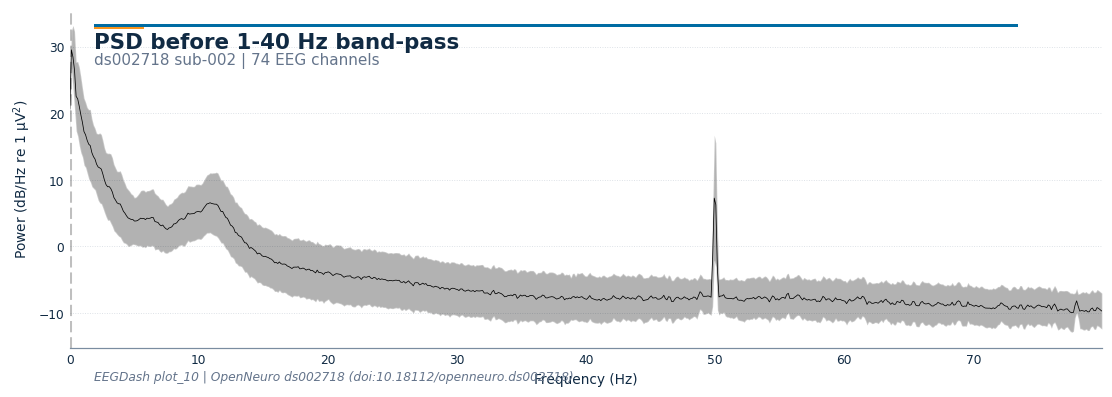

In [139]:
# Antes do processamento
raw_before = record.raw.load_data().copy()
psd = raw_before.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="PSD before 1-40 Hz band-pass",
    subtitle=(
        f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels"
    ),
    source=(f"EEGDash plot_10 | OpenNeuro {DATASET} (doi:10.18112/openneuro.ds002718)"),
)
plt.show()

Agora, vamos aplicar o filtro passa-banda e ver o novo PSD.

In [140]:
L_FREQ = 1
H_FREQ = 40

raw.filter(
    l_freq=L_FREQ,       # Frequência passa-baixa
    h_freq=H_FREQ,       # Frequência passa-alta
    method="fir",
    fir_design="firwin", 
    phase="zero",        # Filtragem sem deslocar picos das ondes no tempo (atraso de fase)
    verbose=False,
)
print(f"highpass={raw.info['highpass']:.2f} Hz, lowpass={raw.info['lowpass']:.2f} Hz")

highpass=1.00 Hz, lowpass=40.00 Hz


Plotting power spectral density (dB=True).


/home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


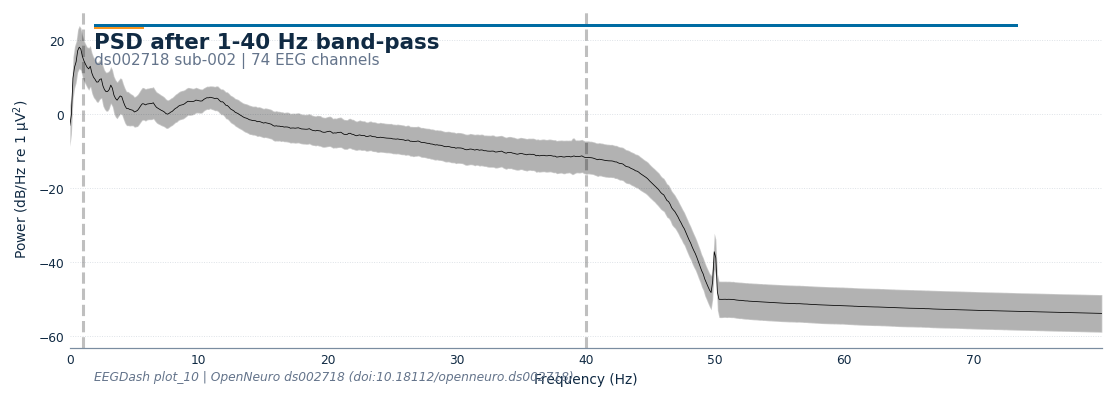

In [141]:
# Depois do processamento
psd = raw.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="PSD after 1-40 Hz band-pass",
    subtitle=(
        f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels"
    ),
    source=(f"EEGDash plot_10 | OpenNeuro {DATASET} (doi:10.18112/openneuro.ds002718)"),
)
plt.show()

### Passo 5: Resampling para 200Hz

O sampling rate original está muito acima do que um conteúdo 1-40Hz precisa. 200Hz mantém uma distância confortável de Nyquist (se usamos 200Hz, a frequẽncia de Nyquist, frequência máxima teórica que o sinal digitalizado consegue registrar sem distorção, é a metade, 100Hz).

Um downsampling para 200Hz também provoca uma economia massiva de memória RAM e acelera o treinamento, ao dividir a quantidade de pontos temporais, e fica dentro do conjunto de frequências para o qual o ASR é calibrado (100, 128, 200, 250, 256, 300, 500, 512 Hz).

In [142]:
TARGET_SFREQ = 200

sfreq_before = raw.info["sfreq"]
shape_before = raw.get_data().shape

raw.resample(TARGET_SFREQ, verbose=False)

print(f"sfreq: {sfreq_before:.1f} Hz -> {raw.info['sfreq']:.1f} Hz")
print(f"raw.get_data().shape: {shape_before} -> {raw.get_data().shape}")

sfreq: 250.0 Hz -> 200.0 Hz
raw.get_data().shape: (74, 747750) -> (74, 598200)


### Passo Final: Aplicar a mesma receita para o dataset inteiro (e criar janelas)

In [147]:
WINDOW_SIZE_S = 2 # Segundos
WINDOW_SAMPLES = int(WINDOW_SIZE_S * TARGET_SFREQ)

preprocess(
    dataset,
    [
        # Definir montagem standard 10-20
        Preprocessor("set_montage", montage="standard_1020", on_missing="ignore"),
        # Definir referência-média comum (CAR)
        Preprocessor("set_eeg_reference", ref_channels="average"),
        # Filtro band-pass (1-40Hz)
        Preprocessor(
            "filter",
            l_freq=L_FREQ,
            h_freq=H_FREQ,
            method="fir",
            fir_design="firwin",
        ),
        # Downsampling
        Preprocessor("resample", sfreq=TARGET_SFREQ),
    ],
)
# Criação das janelas
windows = create_fixed_length_windows(
    dataset,
    window_size_samples=WINDOW_SAMPLES,
    window_stride_samples=WINDOW_SAMPLES,
    drop_last_window=True,
)
x0, _, _ = windows[0]

# Mostrar informações
pd.DataFrame(
    {
        "value": [
            len(windows),
            f"{x0.shape}",
            str(x0.dtype),
            int(TARGET_SFREQ),
            WINDOW_SAMPLES,
        ]
    },
    index=["n_windows", "windows[0][0].shape", "dtype", "sfreq (Hz)", "window_samples"],
)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


/home/arielalves/Desktop/BrainOmni/brainomni/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)



,value
n_windows,1495
windows[0][0].shape,"(74, 400)"
dtype,float32
sfreq (Hz),200
window_samples,400


### Extra: EEGPrep

A classe EEGPrep é uma ferramenta automatizada de limpeza de dados EEG, onde apenas definimos os hiperparâmetros.

In [ ]:
from braindecode.preprocessing import (
    EEGPrep,
)

record_pp = EEGDashDataset(
    cache_dir=CACHE_DIR, dataset=DATASET, subject=SUBJECT, task=TASK
).datasets[0]
raw_full = record_pp.raw.load_data().copy()

EEGPREP_SLICE_S = 30 # Segundos

# Define montagem standard 10-20
raw_full.set_montage("standard_1020", on_missing="ignore")
# Recorta o sinal nos primeiros segundos para testes rápidos
raw_pp = raw_full.copy().crop(0.0, min(EEGPREP_SLICE_S, raw_full.times[-1]))
# Salva uma cópia isolando apenas os canais de EEG
raw_before = raw_pp.copy().pick("eeg")

eegprep = EEGPrep(
    resample_to=TARGET_SFREQ,             # Resampling
    highpass_frequencies=(0.25, 0.75),    # Filtro passa-alta com banda de transição 0.25-0.75 Hz
    bad_channel_corr_threshold=0.8,       # Descarta canais com correlação abaixo de 0.8 com canais vizinhos (eletrodos sem sinal ou com ruído descorrelacionado)
    burst_removal_cutoff=10.0,            # Limiar estatístico de std do ASR para reparar artefatos
    bad_window_max_bad_channels=0.25,     # Marca trechos temporais ruins se mais de 25% dos canais forem corrompidos
    bad_channel_reinterpolate=False,      # Não reconstrói os canais descartados (por interpolação)
    common_avg_ref=True,                  # Aplica CAR
)
eegprep.fn(raw_pp)  # Aplica pré-processamento
raw_after = raw_pp

n_dropped = len(raw_before.ch_names) - len(raw_after.copy().pick("eeg").ch_names)
n_bad_annot = sum(1 for a in raw_after.annotations if "BAD" in a["description"].upper())

# 4. Dividir janelas reais sem vazamento de indivíduos

Dividir aleatoriamente as janelas em decodificadores de EEG entre sujeitos após o conjunto de treinamento atinge uma precisão próxima a 99% e falham em um participante excluído. Isso pois cada gravação produz centenas de janelas sobrepostas do mesmo cérebro, então um embaralhamento uniforme espalha cada sujeito entre tanto o conjunto de treinamento quanto o de teste, e o modelo memoriza impressões digitais cerebrais de cada sujeito (frequência cardíaca, amplitude alpha, impedância do eletrodo) em vez da tarefa que queremos realmente decodificar.

Vamos ver primeiro a falha em janelas sintéticas e, em seguida, vamos reconstruir o split com `eegdash.splits` e um splitter `GroupKFOld-flavoured cross-subject`. A figura fina coloca ambas as estratégias lado a lado.

In [ ]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import eegdash
from collections import Counter

from moabb.evaluations.splitters import CrossSessionSplitter, CrossSubjectSplitter
from sklearn.model_selection import GroupKFold
from eegdash.viz import use_eegdash_style

use_eegdash_style()
warnings.simplefilter("ignore", category=FutureWarning)
SEED = 42
np.random.seed(SEED)
print(f"eegdash {eegdash.__version__}; numpy {np.__version__}")

## 4.1 Por que o vazamento de sujeito ataca o EEG mais profundamente do que outros domínios?

As características específicas de cada sujeito dominam qualquer janela EEG. Largura do crânio, colocação dos eletrodos, condutividade capilar e frequência cardíaca desempenham como uma "assinatura" dos pacientes. 

Brookshire et. al. 2024 quantificou isso em 81 EEGs clínicos em papers de deep-learning: Quando sujeitos aparecem em ambos os lados de um split, a acurácia foi de 0.83, mas em sujeitos que não aparecem em ambos os lados de um split, a mesma arquitetura designava uma acurácia de 0.62. Metade dos estudos avaliados vazou.

Cada janela mantém a assinatura de cada paciente. O conserto disso é estrutural: separamos sujeitos, não janelas. Agrupamos toda janela pelo id do sujeito e deixamos `sklearn.model_selection.GroupKFold` colocar cada sujeito em exatamente um caso de teste.

Para validar o resultado:

- **Leakage Check**. Depois do split, rode `assert_no_leakaage(train_ids, test_ids)`. Isso não deve retornar erro e retornar `True`.
- **Leakage Report**. O JSON `leakage_report` deve mostrar zero.
- **Accuracy Gap**. É esperado que o naive random split performe uma taxa de vazamento de 10-30 pontos.

## 4.1 Construir uma tabela de metadados de janela para 12 sujeitos

In [ ]:
N_SUBJECTS = 12
N_SESSIONS = 2
N_WINDOWS = 8
rows = [
    {
        "subject": f"sub-{s:02d}",
        "session": f"ses-{ses:02d}",
        "run": "run-01",
        "dataset": "ds-windowed-tutorial",
        "sample_id": f"sub-{s:02d}__ses-{ses:02d}__w{w:03d}",
        "target": int((s + w) % 2),
    }
    for s in range(1, N_SUBJECTS + 1)
    for ses in range(1, N_SESSIONS + 1)
    for w in range(N_WINDOWS)
]
raw_metadata = pd.DataFrame(rows)

# For a Braindecode concat-of-WindowsDataset the canonical metadata
# accessor is :meth:`braindecode.datasets.BaseConcatDataset.get_metadata`
# (one row per window, BIDS columns from each record's ``description``
# already merged in). When you start from a hand-built DataFrame, just
# use it directly: pass the frame as ``metadata`` and the column you
# want to stratify on as ``y``.
metadata = raw_metadata
y = metadata["target"].to_numpy()
pd.Series(
    {
        "rows": len(metadata),
        "subjects": metadata["subject"].nunique(),
        "sessions": metadata["session"].nunique(),
        "y dtype": str(y.dtype),
        "class 0 / class 1": (
            f"{int((metadata.target == 0).sum())} / {int((metadata.target == 1).sum())}"
        ),
    },
    name="value",
).to_frame()